# Formelsamling – Sandsynlighedsteori og Statistik
Eksamensforberedelse. Bygget ud fra pensum (forelæsning 1–12) samt prøveeksamensopgaverne.

**Struktur:**
1. Sandsynlighedsteori (grundlæggende, betinget, kombinatorik)
2. Stokastiske variable (diskrete, kontinuerte, simultane)
3. Statistik (estimation, konfidensintervaller, hypotesetest, regression, to-stikprøvetest, simulation)

Hver sektion har formler i markdown + en Python-funktion, du kan bruge direkte til beregninger til eksamen.


In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


: 

## 1. Grundlæggende sandsynlighedsteori

**Aksiomer:**
- 0 ≤ P(A) ≤ 1
- P(S) = 1 (S = udfaldsrummet)
- For disjunkte hændelser: P(A ∪ B) = P(A) + P(B)

**Komplement:** P(Aᶜ) = 1 − P(A)

**Union (generel):** P(A ∪ B) = P(A) + P(B) − P(A ∩ B)

**Betinget sandsynlighed:**

P(A|B) = P(A ∩ B) / P(B),  P(B) > 0

**Multiplikationsregel:** P(A ∩ B) = P(A|B)·P(B) = P(B|A)·P(A)

**Uafhængighed:** A og B er uafhængige, hvis P(A ∩ B) = P(A)·P(B) ⇔ P(A|B) = P(A)

**Loven om total sandsynlighed:** Hvis B₁, B₂, …, Bₙ partitionerer udfaldsrummet:

P(A) = Σᵢ P(A|Bᵢ)·P(Bᵢ)

**Bayes' sætning:**

P(Bᵢ|A) = [P(A|Bᵢ)·P(Bᵢ)] / Σⱼ P(A|Bⱼ)·P(Bⱼ)


## 2. Kombinatorik

**Multiplikationsprincippet:** hvis en opgave består af k trin med n₁, n₂, …, nₖ muligheder, er det samlede antal udfald n₁·n₂·⋯·nₖ

**Fakultet:** n! = n·(n−1)·⋯·2·1,  0! = 1

**Permutationer (ordnet, uden tilbagelægning):**

P(n,k) = n! / (n−k)!

**Kombinationer (uordnet, uden tilbagelægning):**

C(n,k) = (n choose k) = n! / [k!(n−k)!]

**Ordnet med tilbagelægning:** nᵏ

**Uordnet med tilbagelægning:** C(n+k−1, k)


In [2]:
from math import comb, factorial, perm

# Eksempel
n, k = 12, 4
print("Permutationer:", perm(n, k))
print("Kombinationer:", comb(n, k))


Permutationer: 11880
Kombinationer: 495


## 3. Diskrete stokastiske variable

**Sandsynlighedsfunktion (pmf):** f_X(x) = P(X = x),  Σₓ f_X(x) = 1

**Fordelingsfunktion (CDF):** F_X(x) = P(X ≤ x) = Σ_{k≤x} f_X(k)  (trappefunktion)

**Middelværdi (forventning):** E[X] = Σₓ x·f_X(x)

**Varians:** Var(X) = E[X²] − (E[X])²,  hvor E[X²] = Σₓ x²·f_X(x)

**Standardafvigelse:** σ_X = √Var(X)

**Regneregler:**
- E[aX + b] = a·E[X] + b
- Var(aX + b) = a²·Var(X)
- E[X + Y] = E[X] + E[Y] (altid)
- Var(X + Y) = Var(X) + Var(Y) (kun hvis X, Y uafhængige)

### Vigtige diskrete fordelinger

**Binomial fordeling** X ~ Bin(n, p): antal succeser i n uafhængige forsøg

P(X = k) = C(n,k)·pᵏ·(1−p)ⁿ⁻ᵏ,  E[X] = np,  Var(X) = np(1−p)

**Poisson fordeling** X ~ Poisson(λ): antal hændelser i et interval, gennemsnitlig rate λ

P(X = k) = e^(−λ)·λᵏ / k!,  E[X] = λ,  Var(X) = λ

(NB: hvis intervallængden ændres, skal λ skaleres proportionalt, fx λ_halvt_minut = λ_per_minut · 0.5)

**Geometrisk fordeling** X ~ Geo(p): antal forsøg til første succes

P(X = k) = (1−p)^(k−1)·p,  E[X] = 1/p,  Var(X) = (1−p)/p²

**Hypergeometrisk fordeling:** trækning uden tilbagelægning fra endelig population (N, K succeser, n trukket)

P(X = k) = [C(K,k)·C(N−K, n−k)] / C(N,n)


In [3]:
from scipy.stats import binom, poisson, geom, hypergeom

# Binomial
print(binom.pmf(3, n=10, p=0.4))
# Poisson
print(poisson.pmf(3, mu=4))
# P(X >= k) for Poisson
print(1 - poisson.cdf(1, mu=2))


0.21499084799999976
0.19536681481316454
0.593994150290162


## 4. Kontinuerte stokastiske variable

**Tæthedsfunktion (pdf):** f_X(x) ≥ 0,  ∫₋∞^∞ f_X(x) dx = 1

**Fordelingsfunktion (CDF):** F_X(x) = P(X ≤ x) = ∫₋∞^x f_X(t) dt,  f_X(x) = F_X'(x)

**Middelværdi:** E[X] = ∫₋∞^∞ x·f_X(x) dx

**Varians:** Var(X) = E[X²] − (E[X])², hvor E[X²] = ∫₋∞^∞ x²·f_X(x) dx

**P(a ≤ X ≤ b) = F_X(b) − F_X(a) = ∫ₐᵇ f_X(x) dx**

### Vigtige kontinuerte fordelinger

**Uniform fordeling** X ~ Unif(a,b):

f_X(x) = 1/(b−a) for a ≤ x ≤ b,  E[X] = (a+b)/2,  Var(X) = (b−a)²/12

**Eksponentialfordeling** X ~ Exp(λ): ventetid mellem Poisson-hændelser

f_X(x) = λe^(−λx),  F_X(x) = 1 − e^(−λx),  E[X] = 1/λ,  Var(X) = 1/λ²

**Normalfordeling** X ~ N(μ, σ²):

f_X(x) = 1/(σ√(2π)) · e^(−(x−μ)²/(2σ²))

Standardisering: Z = (X − μ)/σ ~ N(0,1)

**Invers CDF / kvantiler:** F_X⁻¹(p) er den værdi x, hvor F_X(x) = p. For diskrete fordelinger findes x ved at finde det interval i den kumulerede fordeling, hvor p falder.


In [4]:
from scipy.stats import uniform, expon, norm

# Normalfordeling
print(norm.cdf(1.96))          # P(Z <= 1.96)
print(norm.ppf(0.975))         # 97.5%-kvantil (invers CDF)

# Eksponentialfordeling
print(expon.cdf(2, scale=1/0.5))  # lambda = 0.5


0.9750021048517795
1.959963984540054
0.6321205588285577


## 5. Simultane (fælles) fordelinger

**Diskret simultan pmf:** f_{X,Y}(x,y) = P(X=x, Y=y),  ΣΣ f_{X,Y}(x,y) = 1

**Kontinuert simultan pdf:** ∬ f_{X,Y}(x,y) dx dy = 1 (find evt. konstanten c ved at sætte integralet/summen = 1)

**Marginal fordeling:**

f_X(x) = Σ_y f_{X,Y}(x,y)   (diskret)     eller     f_X(x) = ∫ f_{X,Y}(x,y) dy   (kontinuert)

**Betinget fordeling:** f_{X|Y}(x|y) = f_{X,Y}(x,y) / f_Y(y)

**Uafhængighed:** X, Y uafhængige ⇔ f_{X,Y}(x,y) = f_X(x)·f_Y(y) for alle x,y

**Kovarians:** Cov(X,Y) = E[XY] − E[X]E[Y]

**Korrelation:** ρ_{X,Y} = Cov(X,Y) / (σ_X·σ_Y)

**Varians af sum:** Var(X+Y) = Var(X) + Var(Y) + 2Cov(X,Y)

**Konvolution (sum af uafhængige variable):**

f_{X+Y}(z) = Σ_x f_X(x)·f_Y(z−x)  (diskret)   eller   ∫ f_X(x)·f_Y(z−x) dx (kontinuert)


## 6. Estimation og Central Grænseværdisætning (CLT)

**Stikprøvegennemsnit:** x̄ = (1/n)·Σxᵢ  — estimator for μ

**Stikprøvevarians (unbiased):** s² = 1/(n−1) · Σ(xᵢ − x̄)²

**Central grænseværdisætning (CLT):** For store n (typisk n ≥ 30):

X̄ ≈ N(μ, σ²/n)   ⇒   Z = (X̄ − μ) / (σ/√n) ≈ N(0,1)

**Bias:** Bias(θ̂) = E[θ̂] − θ. Estimator er unbiased hvis Bias = 0.

**MSE (Mean Squared Error):** MSE(θ̂) = Var(θ̂) + Bias(θ̂)²

**Maximum Likelihood (MLE):** find θ som maksimerer likelihood-funktionen L(θ) = Π f(xᵢ; θ), typisk ved at maksimere log L(θ)


## 7. Konfidensintervaller

**Generel form:** estimat ± (kritisk værdi)·(standard error)

**For middelværdi, σ kendt (Z-interval):**

x̄ ± z_(α/2) · σ/√n

**For middelværdi, σ ukendt (t-interval), df = n−1:**

x̄ ± t_(α/2, n−1) · s/√n

**t-fordelingen** ligner normalfordelingen men har tungere haler; bruges når σ er ukendt og estimeres med s. Konvergerer mod N(0,1) for store n.

**Fortolkning:** Et 95% konfidensinterval betyder, at hvis man gentog forsøget mange gange, ville 95% af de beregnede intervaller indeholde den sande μ.


In [5]:
n = 12
xbar = 100
s = 10
alpha = 0.05
df = n - 1

t_crit = stats.t.ppf(1 - alpha/2, df)
margin = t_crit * s/np.sqrt(n)
print(f"KI: ({xbar-margin:.3f}, {xbar+margin:.3f})")


KI: (93.646, 106.354)


## 8. Hypotesetest (én stikprøve)

**Trin i hypotesetest:**
1. Opstil H₀ og H₁
2. Vælg signifikansniveau α (typisk 0.05)
3. Beregn teststørrelse
4. Beregn p-værdi (eller find kritisk værdi) og konkluder

**Z-test (σ kendt):**

Z = (x̄ − μ₀) / (σ/√n)

**t-test (σ ukendt), df = n−1:**

t = (x̄ − μ₀) / (s/√n)

**Beslutningsregel (p-værdi metode):** afvis H₀ hvis p-værdi < α

**p-værdi:**
- Tosidet test (H₁: μ ≠ μ₀): p = 2·(1 − Φ(|z|)) eller 2·(1 − t_cdf(|t|, df))
- Ensidet test (H₁: μ > μ₀): p = 1 − Φ(z) eller 1 − t_cdf(t, df)
- Ensidet test (H₁: μ < μ₀): p = Φ(z) eller t_cdf(t, df)

**Type I fejl (α):** afvise H₀ når H₀ er sand
**Type II fejl (β):** ikke afvise H₀ når H₀ er falsk


In [6]:
xbar, mu0, s, n = 2955, 3000, 100, 12   # eksempel
t_stat = (xbar - mu0)/(s/np.sqrt(n))
p_value = 2*(1 - stats.t.cdf(abs(t_stat), df=n-1))
print("t =", t_stat, " p =", p_value)

# Med scipy direkte på data:
# t_stat, p_value = stats.ttest_1samp(data, popmean=mu0)


t = -1.5588457268119895  p = 0.14732123601931102


## 9. Sammenligning af to stikprøver (to-sample tests)

**Parret vs uparret:** Brug parret test hvis observationerne er naturligt forbundne (fx før/efter på samme individ). Ellers uparret.

### Uparret, σ kendt:

Z = [(x̄₁ − x̄₂) − δ₀] / √(σ₁²/n₁ + σ₂²/n₂)

### Uparret, σ ukendt, antaget ens varians (pooled variance):

**Pooled varians:**

s_p² = [(n₁−1)s₁² + (n₂−1)s₂²] / (n₁ + n₂ − 2)

**Standard error:**

SE = s_p · √(1/n₁ + 1/n₂)

**Teststørrelse:**

t = [(x̄₁ − x̄₂) − δ₀] / SE,  df = n₁ + n₂ − 2

**Konfidensinterval for μ₁ − μ₂:**

(x̄₁ − x̄₂) ± t_(α/2, df) · SE

### Parret test:

Beregn differenser dᵢ = x₁ᵢ − x₂ᵢ, og udfør en ét-stikprøve t-test på differencerne:

t = (d̄ − 0) / (s_d/√n),  df = n−1


In [7]:
x1bar, x2bar = 40.575, 44.53
n1, n2 = 12, 10
s1sq, s2sq = 0.83, 0.65   # eksempel-varianser

sp2 = ((n1-1)*s1sq + (n2-1)*s2sq)/(n1+n2-2)
SE = np.sqrt(sp2)*np.sqrt(1/n1 + 1/n2)
t_stat = (x1bar - x2bar - 0)/SE
df = n1+n2-2
p_value_onesided = stats.t.cdf(t_stat, df)  # H1: mu1 < mu2
print("pooled var:", sp2, "t:", t_stat, "p (ensidet):", p_value_onesided)

# Direkte med scipy (to uafhængige stikprøver, ens varians):
# t_stat, p_value = stats.ttest_ind(sample1, sample2, equal_var=True)


pooled var: 0.749 t: -10.672959503855665 p (ensidet): 5.233483655429716e-10


## 10. Simpel lineær regression

**Model:** Y = β₀ + β₁X + ε,  ε ~ N(0, σ²)

**Mindste kvadraters estimater:**

β̂₁ = Σ(xᵢ−x̄)(yᵢ−ȳ) / Σ(xᵢ−x̄)²

β̂₀ = ȳ − β̂₁·x̄

**Fittet linje:** ŷᵢ = β̂₀ + β̂₁xᵢ

**Residualer:** eᵢ = yᵢ − ŷᵢ

**Estimeret varians:**

σ̂² = Σeᵢ² / (n−2)

**Test for hældning (β₁):**

H₀: β₁ = 0  vs.  H₁: β₁ ≠ 0

t = β̂₁ / SE(β̂₁),  df = n−2,  hvor SE(β̂₁) = σ̂ / √(Σ(xᵢ−x̄)²)

**Konfidensinterval for β₁:**

β̂₁ ± t_(α/2, n−2) · SE(β̂₁)


In [8]:
x = np.array([1,2,3,4,5])
y = np.array([2.1, 3.9, 6.2, 7.8, 10.1])

slope, intercept, r, p, se = stats.linregress(x, y)
print("beta1 (hældning):", slope, " beta0 (skæring):", intercept)
print("p-værdi for beta1:", p, " SE:", se)


beta1 (hældning): 1.99  beta0 (skæring): 0.05000000000000071
p-værdi for beta1: 5.9415391117559265e-05  SE: 0.059721576223897795


## 11. Sampling og simulation

**Invers transformationsmetode (kontinuert):**
1. Find F_X(x)
2. Generér U ~ Unif(0,1)
3. Løs U = F_X(x) for x → X = F_X⁻¹(U)

**Invers transformation (diskret):** Match U mod de kumulerede sandsynligheder (trappetrin i CDF'en) og aflæs x i det interval, U falder i.

**Box–Muller-metoden** (generér N(0,1) fra to uniforme variable U₁, U₂ ~ Unif(0,1)):

Z₁ = √(−2 ln U₁) · cos(2πU₂)
Z₂ = √(−2 ln U₁) · sin(2πU₂)

**Transformation til vilkårlig normalfordeling:** hvis Z ~ N(0,1), så er X = μ + σZ ~ N(μ, σ²)

**Simulation af diskret fordeling i Python:** brug `np.random.choice(values, size=n, p=probabilities)`


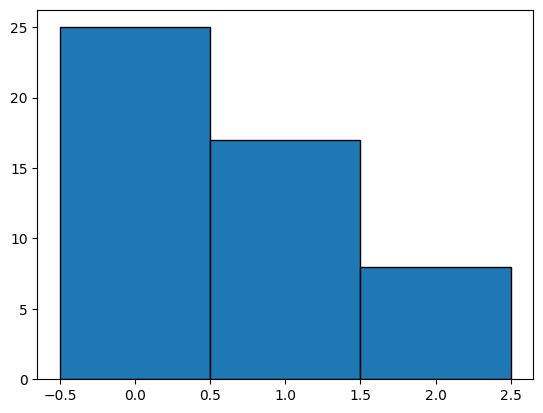

In [9]:
# Invers transformation - eksponentialfordeling
lam = 0.5
U = np.random.uniform(0, 1, size=1000)
X = -np.log(1-U)/lam   # F^-1(U) for Exp(lambda)

# Box-Muller
U1 = np.random.uniform(0,1,1000)
U2 = np.random.uniform(0,1,1000)
Z1 = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)

# Simuler diskret variabel
X_disc = np.random.choice([0,1,2], size=50, p=[0.5,0.3,0.2])
plt.hist(X_disc, bins=[-0.5,0.5,1.5,2.5], edgecolor='black')
plt.show()


## 12. Quick-reference: hvilken metode/test skal jeg bruge?

| Situation | Metode |
|---|---|
| Én stikprøve, σ kendt | Z-test / Z-konfidensinterval |
| Én stikprøve, σ ukendt | t-test / t-konfidensinterval (df = n−1) |
| To uafhængige stikprøver, ens varians antaget | Pooled t-test (df = n₁+n₂−2) |
| To stikprøver, naturligt forbundne (før/efter) | Parret t-test på differencer (df = n−1) |
| Sammenhæng mellem to kvantitative variable | Lineær regression, test på β₁ |
| Antal succeser ud af n forsøg | Binomialfordeling |
| Antal hændelser pr. tidsenhed | Poissonfordeling |
| Ventetid mellem hændelser | Eksponentialfordeling |
| Trækning uden tilbagelægning | Hypergeometrisk fordeling |
| Simulering af fordeling | Invers transformation / Box–Muller |

**Husk altid:** tjek om variablen er diskret (brug summer, pmf, trappe-CDF) eller kontinuert (brug integraler, pdf, glat CDF) — det afgør hvilke formler der er relevante.
